# 03 · Train
Standardize (fit on train only), train LSTM, plot loss curves.

In [1]:
import sys; sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from quant_dl.data import download
from quant_dl.features import FEATURE_COLUMNS, WindowDataset, add_indicators, make_windows, chronological_split
from quant_dl.models import LSTMModel
from quant_dl.train import get_device, train_model

In [2]:
WINDOW = 20
df = add_indicators(download('AAPL', '2018-01-01', '2025-01-01')).dropna()
X, y = make_windows(df, FEATURE_COLUMNS, WINDOW)
(X_train, y_train), (X_val, y_val), (X_test, y_test) = chronological_split(X, y)

Standardize each feature using **train-split statistics only** (no look-ahead).

In [3]:
mu = X_train.reshape(-1, X_train.shape[-1]).mean(axis=0)
sigma = X_train.reshape(-1, X_train.shape[-1]).std(axis=0)
X_train_s = (X_train - mu) / sigma
X_val_s = (X_val - mu) / sigma
X_test_s = (X_test - mu) / sigma

In [4]:
torch.manual_seed(42)
device = get_device()
print('device:', device)
model = LSTMModel(n_features=len(FEATURE_COLUMNS), hidden_size=64, num_layers=2)
history = train_model(
    model,
    DataLoader(WindowDataset(X_train_s, y_train), batch_size=64, shuffle=True),
    DataLoader(WindowDataset(X_val_s, y_val), batch_size=256),
    epochs=100, lr=1e-3, patience=10, device=device,
)
print(f'stopped after {len(history["train_loss"])} epochs')

device: mps


stopped after 37 epochs


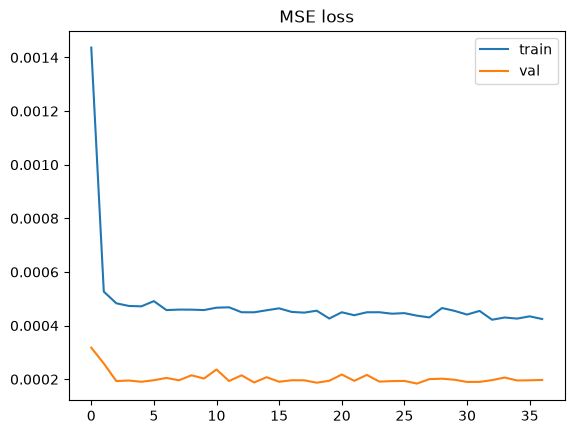

In [5]:
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.legend(); plt.title('MSE loss'); plt.show()

Save model + scaler stats for the backtest notebook.

In [6]:
import pathlib
pathlib.Path('../checkpoints').mkdir(exist_ok=True)
torch.save({'state_dict': model.state_dict(), 'mu': mu, 'sigma': sigma, 'window': WINDOW},
           '../checkpoints/lstm_aapl.pt')